08 - Benchmark comparison chart: Plot top
5 funds vs Nifty 50 and Nifty 100 over
3 years. Compute tracking error.

Fund 148567 -> Merged rows: 1149
Fund 120843 -> Merged rows: 1149
Fund 120505 -> Merged rows: 1149
Fund 148569 -> Merged rows: 1149
Fund 100033 -> Merged rows: 1149
   amfi_code  tracking_error
0     148567        0.189664
1     120843        0.206425
2     120505        0.231968
3     148569        0.217365
4     100033        0.228699
Saved


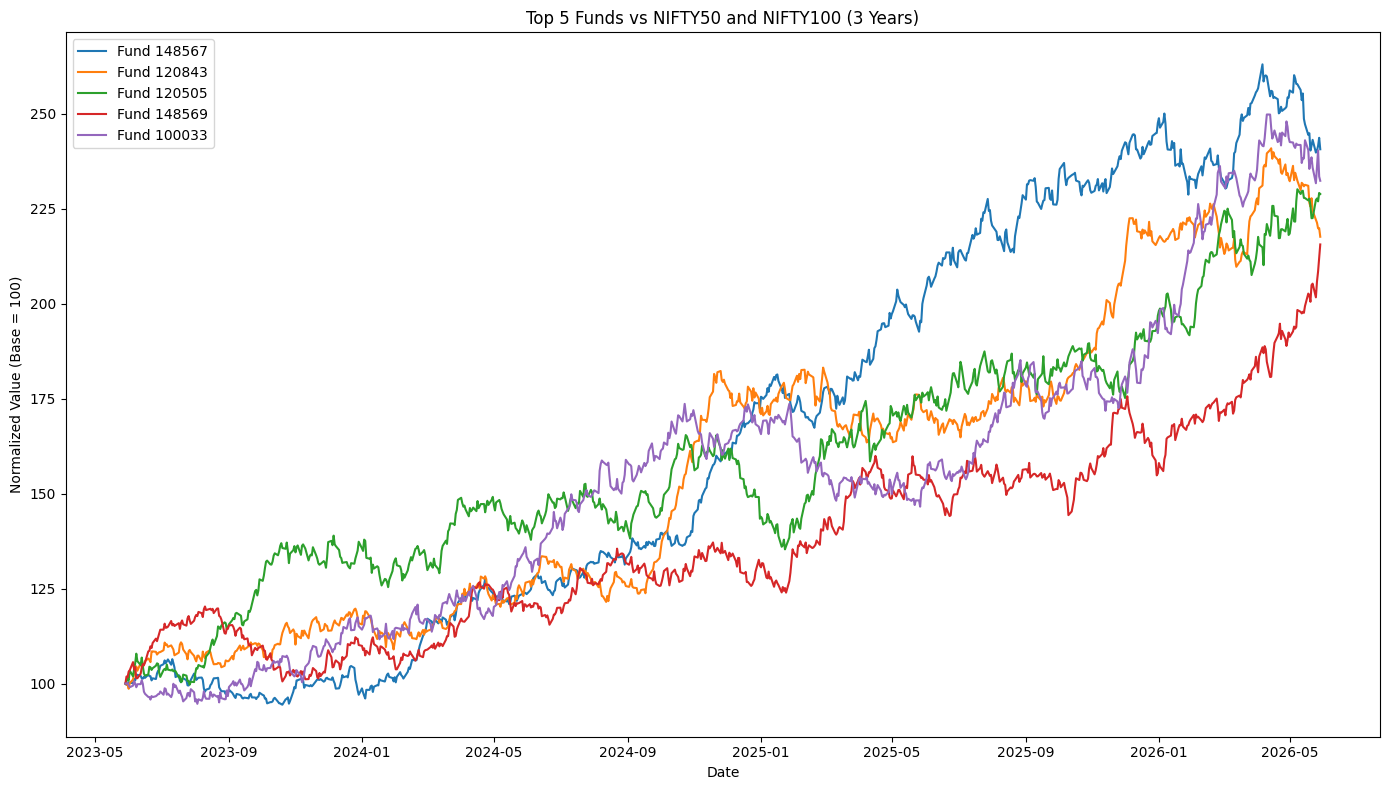

<Figure size 640x480 with 0 Axes>

In [ ]:
tracking_error_results = []

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

for code in top_codes:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    fund["fund_return"] = (
        fund["nav"].pct_change()
    )

    merged = fund.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    print(
        f"Fund {code} -> Merged rows:",
        len(merged)
    )

    if len(merged) == 0:
        continue

    tracking_error = (
        (
            merged["fund_return"]
            - merged["benchmark_return"]
        ).std()
        * np.sqrt(252)
    )

    tracking_error_results.append(
        {
            "amfi_code": code,
            "tracking_error": tracking_error
        }
    )

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

print(tracking_error_df)

tracking_error_df.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "tracking_error.csv",
    index=False
)

print("Saved")

plt.figure(figsize=(14,8))

for code in top_codes:

    temp = fund_chart[
        fund_chart["series"] == str(code)
    ]

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {code}"
    )

for temp in benchmark_lines:

    idx = temp["index_name"].iloc[0]

    plt.plot(
        temp["date"],
        temp["normalized"],
        linewidth=3,
        label=idx
    )

plt.title(
    "Top 5 Funds vs NIFTY50 and NIFTY100 (3 Years)"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.tight_layout()

plt.show()
plt.savefig(
    BASE_DIR /
    "Reports" /
    "benchmark_comparison.png",
    bbox_inches="tight"
)

07 - Build Fund Scorecard (composite
score 0-100): Score = 30%×(3yr
return rank) + 25%×(Sharpe rank) +
20%×(Alpha rank) + 15%×(Expense
ratio rank, inverse) + 10%×(Max DD
rank, inverse)


In [ ]:
cagr = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "cagr_report.csv"
)

sharpe = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "sharpe_values.csv"
)

sortino = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "sortino_values.csv"
)

alpha = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "alpha_beta.csv"
)


ranking = (
    cagr[["amfi_code", "cagr_3yr"]]
    .merge(sharpe, on="amfi_code")
    .merge(sortino, on="amfi_code")
    .merge(alpha[["amfi_code", "alpha"]], on="amfi_code")
)

for col in [
    "cagr_3yr",
    "sharpe_ratio",
    "sortino_ratio",
    "alpha"
]:

    ranking[col + "_norm"] = (
        ranking[col] - ranking[col].min()
    ) / (
        ranking[col].max()
        - ranking[col].min()
    )

ranking["fund_score"] = (
    0.40 * ranking["cagr_3yr_norm"]
    + 0.30 * ranking["sharpe_ratio_norm"]
    + 0.20 * ranking["sortino_ratio_norm"]
    + 0.10 * ranking["alpha_norm"]
)

ranking = ranking.sort_values(
    "fund_score",
    ascending=False
)

ranking["rank"] = range(
    1,
    len(ranking) + 1
)

ranking.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "fund_rankings.csv",
    index=False
)

print("Saved")

ranking[
    [
        "rank",
        "amfi_code",
        "fund_score"
    ]
].head(10)

"""print(cagr.head())
print(sharpe.head())
print(sortino.head())
print(alpha.head())"""

Saved


'print(cagr.head())\nprint(sharpe.head())\nprint(sortino.head())\nprint(alpha.head())'

06 - Compute Maximum Drawdown:
max_dd = min(NAV / running_max -
1) Highlight worst drawdown period
for each fund


In [21]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

drawdown_results = []

for code in nav["amfi_code"].unique():

    fund = (
        nav[nav["amfi_code"] == code]
        .copy()
    )

    fund["running_peak"] = (
        fund["nav"].cummax()
    )

    fund["drawdown"] = (
        fund["nav"]
        / fund["running_peak"]
        - 1
    )

    max_dd = fund["drawdown"].min()

    drawdown_results.append([
        code,
        max_dd
    ])

max_drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_drawdown_df.head()

max_drawdown_df.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "max_drawdown.csv",
    index=False
)

print("Saved")

max_drawdown_df.sort_values(
    "max_drawdown"
).head(10)


Saved


,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


05 - Compute Alpha & Beta vs benchmark:
Regress fund returns on Nifty 100
returns (OLS) Alpha = intercept * 252,
Beta = slope Use
scipy.stats.linregress

In [37]:
# ==========================
# DELIVERABLE 5: ALPHA & BETA
# ==========================

import pandas as pd
import numpy as np

# --------------------------
# 1. Load Benchmark Data
# --------------------------

benchmark = pd.read_csv(
    BASE_DIR / "Data" / "raw" / "10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print("Benchmark Shape:", benchmark.shape)
print("\nAvailable Benchmarks:")
print(benchmark["index_name"].unique())

# --------------------------
# 2. Filter NIFTY100
# --------------------------

benchmark = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print("\nNIFTY100 Rows:", len(benchmark))

if len(benchmark) == 0:
    raise ValueError(
        "No rows found for NIFTY100. Check benchmark names."
    )

# --------------------------
# 3. Benchmark Daily Returns
# --------------------------

benchmark = benchmark.sort_values(
    "date"
)

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

print("\nBenchmark Return Sample:")
print(
    benchmark[
        ["date", "benchmark_return"]
    ].head()
)

# --------------------------
# 4. Prepare NAV Data
# --------------------------

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print("\nNAV Shape:", nav.shape)

# --------------------------
# 5. Check Date Overlap
# --------------------------

print(
    "\nNAV Date Range:",
    nav["date"].min(),
    "to",
    nav["date"].max()
)

print(
    "Benchmark Date Range:",
    benchmark["date"].min(),
    "to",
    benchmark["date"].max()
)

# --------------------------
# 6. Alpha Beta Calculation
# --------------------------

alpha_beta_results = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][
        ["date", "daily_return"]
    ].copy()

    merged = fund.merge(
        benchmark[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    # skip funds with insufficient history
    if len(merged) < 30:
        continue

    covariance = np.cov(
        merged["daily_return"],
        merged["benchmark_return"]
    )[0, 1]

    variance = np.var(
        merged["benchmark_return"]
    )

    if variance == 0:
        continue

    beta = covariance / variance

    alpha = (
        merged["daily_return"].mean()
        - beta *
        merged["benchmark_return"].mean()
    ) * 252

    alpha_beta_results.append(
        [
            code,
            alpha,
            beta
        ]
    )

# --------------------------
# 7. Create DataFrame
# --------------------------

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

print(
    "\nAlpha Beta Shape:",
    alpha_beta_df.shape
)

print(
    "\nTop 10 Alpha Funds:"
)

display(
    alpha_beta_df
    .sort_values(
        "alpha",
        ascending=False
    )
    .head(10)
)

# --------------------------
# 8. Save Output
# --------------------------

output_path = (
    BASE_DIR /
    "Data" /
    "processed" /
    "alpha_beta.csv"
)

alpha_beta_df.to_csv(
    output_path,
    index=False
)

print(
    "\nSaved:",
    output_path
)

Benchmark Shape: (8050, 3)

Available Benchmarks:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

NIFTY100 Rows: 1150

Benchmark Return Sample:
           date  benchmark_return
1150 2022-01-03               NaN
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150

NAV Shape: (46000, 4)

NAV Date Range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Benchmark Date Range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00

Alpha Beta Shape: (40, 3)

Top 10 Alpha Funds:


,amfi_code,alpha,beta
21,119598,0.303370,-0.023216
39,149324,0.300578,0.011465
25,120505,0.292636,0.000549
36,148569,0.282703,0.018150
30,120843,0.273305,-0.022849
2,100033,0.271953,0.005108
34,148567,0.269837,0.023704
38,149323,0.265986,-0.002525
16,119094,0.260768,-0.066323
19,119551,0.232011,-0.031779



Saved: c:\Users\RITIK KUMAR\OneDrive\Desktop\Bluestock_mf_capstone\Data\processed\alpha_beta.csv


04 - Compute Sortino Ratio: Sortino = (Rp
- Rf) / Downside_Std where
Downside_Std uses only negative
return days


In [11]:
rf_annual = 0.065
rf_daily = rf_annual / 252

import numpy as np

sortino_results = []

for code in nav["amfi_code"].unique():

    returns = (
        nav.loc[
            nav["amfi_code"] == code,
            "daily_return"
        ]
        .dropna()
    )

    if len(returns) > 0:

        avg_return = returns.mean()

        downside_returns = returns[
            returns < 0
        ]

        if len(downside_returns) > 0:

            downside_std = downside_returns.std()

            sortino = (
                (avg_return - rf_daily)
                / downside_std
            ) * np.sqrt(252)

            sortino_results.append([
                code,
                sortino
            ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

sortino_df.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "sortino_values.csv",
    index=False
)

print("Saved")

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

Saved


,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


03 - Compute Sharpe Ratio: Sharpe = (Rp
- Rf) / Std(Rp) Use Rf = 6.5% (RBI
repo rate proxy) Annualise with
sqrt(252)


In [10]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
rf_annual = 0.065
rf_daily = rf_annual / 252

import numpy as np

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = (
        nav.loc[
            nav["amfi_code"] == code,
            "daily_return"
        ]
        .dropna()
    )

    if len(returns) > 0:

        avg_return = returns.mean()

        std_return = returns.std()

        sharpe = (
            (avg_return - rf_daily)
            / std_return
        ) * np.sqrt(252)

        sharpe_results.append([
            code,
            sharpe
        ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

sharpe_df.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "sharpe_values.csv",
    index=False
)

print("Saved")

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

Saved


,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


02 - Calculate CAGR for 1yr, 3yr, 5yr
periods: CAGR = (NAV_end /
NAV_start) ^ (1/n) - 1 for SBI
Bluechip, HDFC Top 100, etc.


In [9]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd().parent

nav = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "nav_history_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

results = []

for code in nav["amfi_code"].unique():

    fund = (
        nav[nav["amfi_code"] == code]
        .sort_values("date")
    )

    latest_date = fund["date"].max()

    row = {
        "amfi_code": code
    }

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        hist = fund[
            fund["date"] >= start_date
        ]

        if len(hist) > 1:

            start_nav = hist.iloc[0]["nav"]
            end_nav = hist.iloc[-1]["nav"]

            row[f"cagr_{years}yr"] = (
                calculate_cagr(
                    start_nav,
                    end_nav,
                    years
                )
            )

        else:
            row[f"cagr_{years}yr"] = np.nan

    results.append(row)

cagr_report = pd.DataFrame(results)

cagr_report.head()

cagr_report.to_csv(
    BASE_DIR / "Data" / "processed" / "cagr_report.csv",
    index=False
)

print("Saved")

cagr_report.sort_values(
    "cagr_5yr",
    ascending=False
).head(10)

Saved


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
25,120505,0.296047,0.317775,0.283768
21,119598,0.827761,0.266699,0.280332
39,149324,0.651387,0.270004,0.279174
36,148569,0.397518,0.291789,0.276299
34,148567,0.203607,0.340009,0.267993
30,120843,0.266571,0.295828,0.267425
2,100033,0.532324,0.324425,0.260741
38,149323,0.214812,0.268700,0.256118
16,119094,0.222611,0.351118,0.244453
19,119551,0.604373,0.304565,0.223849


01 - Compute daily returns for all funds:
daily_return = nav_t / nav_t-1 - 1
Annualised return = (1 +
daily_return).prod()^(252/n) - 1

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd().parent

nav = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "nav_history_clean.csv"
)

print(nav.head())

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

annualized_returns = (
    nav.groupby("amfi_code")
       .apply(
           lambda x:
           (1 + x["daily_return"].dropna()).prod()
           ** (252 / len(x["daily_return"].dropna()))
           - 1
       )
       .reset_index()
)

annualized_returns.columns = [
    "amfi_code",
    "annualized_return"
]

annualized_returns.sort_values(
    "annualized_return",
    ascending=False
).head(10)

annualized_returns.to_csv(
    BASE_DIR / "Data" / "processed" / "annualized_returns.csv",
    index=False
)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
